In [7]:
from sklearn.linear_model import Lasso,LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
import pandas as pd
from sklearn.model_selection import train_test_split

In [8]:
insurance_data=pd.read_csv("insurance.csv")

In [9]:
# one hot encoding

X= insurance_data.drop(columns=["charges"])
y=insurance_data["charges"]

X= pd.get_dummies(X, columns=["region"], drop_first=True, dtype=int)



X["sex"]=X["sex"].map({"female":0 , "male":1})
X["smoker"]=X["smoker"].map({"no":0 , "yes":1})


In [10]:
# high age and smoker will impact model more
X["age_smoker"]=X["age"]* X["smoker"]
# bmi smoker
X["bmi_smoker"]=X["bmi"]* X["smoker"]
# age bmi
# X["age_bmi"]= X["age"] * X["bmi"]

In [11]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

MSE for alpha=0.0001: 20922607.131011527
MSE for alpha=0.001: 20922599.871035967
MSE for alpha=0.01: 20922527.32662988
MSE for alpha=0.1: 20921803.698431373
MSE for alpha=1: 20914832.63508914
MSE for alpha=10: 20872844.79479669
MSE for alpha=20: 20877828.532378834
MSE for alpha=30: 20937537.133939777
MSE for alpha=40: 21046489.29389078
MSE for alpha=50: 21196929.86960891
MSE for alpha=70: 21634290.385158475
MSE for alpha=100: 22423172.68602325


<Axes: >

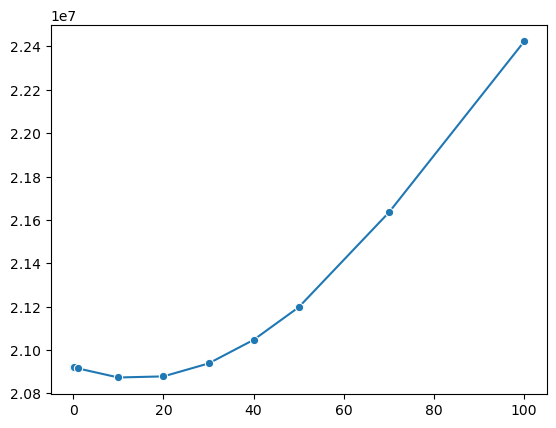

In [12]:
#using simple layman method --loop-- not practical
# just for understanding how alpha values affect the model

import seaborn as sns
alphas=[0.0001,0.001,0.01,0.1,1,10,20,30,40,50,70,100]
mses=[]
for a in alphas:
    lasso_model = Lasso( alpha=a)
    # alpha is lambda value in regression. it is different from learning rate.
    # model selection and train
    lasso_model.fit(X_train,y_train)
    
    y_pred = lasso_model.predict(X_test)
    
    # mean squared error
    mse = mean_squared_error(y_test,y_pred)
    print(f"MSE for alpha={a}: {mse}")
    mses.append(mse)

sns.lineplot(x=alphas,y=mses,marker="o")

In [15]:
# lasso CV
# cross validation
# splits data into multiple folds and runs the iterations.  
# trains and tests on those folds (fold divided into train and test data)

from sklearn.linear_model import LassoCV
# a=[0.001,0.01,0.1,1,10,20,20,30,50,70,100,150,200]

lasso_cv_model=LassoCV(
    # alphas=a, # alpha values. if we pass alpha model will select best value from the passed values. otherwise it will select best automatically
    cv=5,     # no of folds
    max_iter=10000,
    random_state=42
)

lasso_cv_model.fit(X_train,y_train)
print("best alpha value:",lasso_cv_model.alpha_)

y_pred=lasso_cv_model.predict(X_test)
mse = mean_squared_error(y_test,y_pred)
print(f"MSE for {lasso_cv_model.alpha_}: {mse}")

# r2
r2=r2_score(y_test,y_pred)
print("r2: ",r2)

best alpha value: 0.001
MSE for 0.001: 20922599.871035967
r2:  0.8652317499151699
